# 02. EDA и Feature Engineering (v2 — без утечки)

**Цель:** загрузить данные, рассчитать ERR, сделать EDA, сконструировать признаки.

**На выходе:**
- `data/processed/eda_full.csv` — все колонки для анализа
- `data/processed/model_ready.csv` — только безопасные признаки (без data leakage) + таргет

## 0. Импорты

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('OK')

OK


## 1. Загрузка данных

In [39]:
df = pd.read_csv('../data/raw/all_posts_raw.csv')
print(f'Загружено: {len(df)} постов, {len(df.columns)} колонок')
df.head(5)

Загружено: 70476 постов, 29 колонок


,platform,channel_username,channel_title,followers_count,post_id,post_text,text_length,has_media,media_type,has_photo,...,forwards_count,comments_count,reactions_count,replies_count,is_advert,country,city,published_at,collected_at,ad_type
0,Telegram,@habr_com,Хабр,129869,68805,Деградация VPN и allowlist провайдеров: автома...,755,True,NaN,True,...,202,0,NaN,2.0,False,NaN,NaN,2026-06-03T17:00:45+00:00,2026-06-03T20:01:00.889021+00:00,other
1,Telegram,@habr_com,Хабр,129869,68804,Как экспортёры фасоли и билетёры построили инд...,715,True,NaN,True,...,49,0,NaN,1.0,False,NaN,NaN,2026-06-03T13:01:18+00:00,2026-06-03T20:01:00.889123+00:00,other
2,Telegram,@habr_com,Хабр,129869,68803,Спросите эксперта: всё о безопасности контейне...,483,True,NaN,True,...,36,0,NaN,0.0,False,NaN,NaN,2026-06-03T11:01:24+00:00,2026-06-03T20:01:00.889190+00:00,other
3,Telegram,@habr_com,Хабр,129869,68802,Claude Opus 4.8 занял первое место в ARC-AGI-3...,1831,True,NaN,True,...,131,0,NaN,9.0,False,NaN,NaN,2026-06-03T10:05:12+00:00,2026-06-03T20:01:00.893191+00:00,other
4,Telegram,@habr_com,Хабр,129869,68801,Самодельный «ретрокомпьютер» из трёх Arduino\n...,679,True,NaN,True,...,58,0,NaN,5.0,False,NaN,NaN,2026-06-03T09:01:18+00:00,2026-06-03T20:01:00.893287+00:00,other


In [40]:
print('Пропуски (%):')
print((df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False).head(10))
print(f'\nПлатформы: {df["platform"].value_counts().to_dict()}')
print(f'Рекламных: {df["is_advert"].sum()} / {len(df)} = {df["is_advert"].mean():.2%}')

# Гео (новое)
if 'country' in df.columns:
    print(f'\nГео заполнено: {df["country"].notna().sum()}/{len(df)}')
    print(df['country'].value_counts().head(5))

Пропуски (%):
city               100.0
country            100.0
post_text            4.0
media_type           3.1
n_links_raw          3.1
n_hashtags_raw       3.1
n_mentions_raw       3.1
reactions_count      3.1
replies_count        1.6
post_id              0.0
dtype: float64

Платформы: {'Telegram': 60040, 'VK': 10436}
Рекламных: 1145 / 70476 = 1.62%

Гео заполнено: 0/70476
Series([], Name: count, dtype: int64)


## 2. Расчёт таргета ERR

$$ERR = \frac{Likes + Comments + Forwards}{Views} \times 100\%$$

In [41]:
df["total_engagement"] = df["likes_count"] + df["comments_count"] + df["forwards_count"]
df["ERR"] = np.where(
    df["views_count"] > 0,
    (df["total_engagement"] / df["views_count"]) * 100,
    np.nan
)
print(f"До: {len(df)}")
df = df[df["views_count"] > 0].copy()
print(f"После views=0: {len(df)}")
outliers = len(df[df["ERR"] > 100])
df = df[df["ERR"] <= 100].copy()
print(f"После ERR>100%: {len(df)} (убрано {outliers})")

ch_counts = df.groupby("channel_username").size()
good_ch = ch_counts[ch_counts >= 50].index
df = df[df["channel_username"].isin(good_ch)].copy()
print(f"Каналов 50+: {len(good_ch)} (постов: {len(df)})")

df["ch_mean"] = df.groupby("channel_username")["ERR"].transform("mean")
df["ch_std"] = df.groupby("channel_username")["ERR"].transform("std").fillna(0)
before = len(df)
df = df[df["ERR"] <= df["ch_mean"] + 3 * df["ch_std"]].copy()
print(f"После удаления выбросов: {len(df)} (убрано {before - len(df)})")
df.drop(columns=["ch_mean", "ch_std"], inplace=True)

print(f"ERR: mean={df["ERR"].mean():.2f}%, median={df["ERR"].median():.2f}%")


До: 70476
После views=0: 70211
После ERR>100%: 69949 (убрано 262)
Каналов 50+: 526 (постов: 68699)
После удаления выбросов: 67410 (убрано 1289)
ERR: mean=1.44%, median=0.24%


## 3. EDA

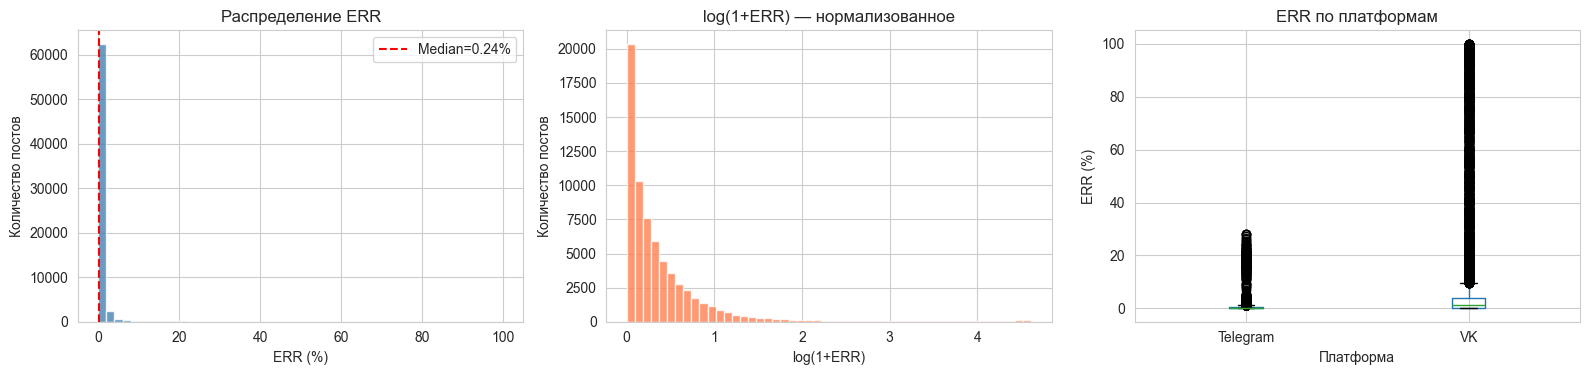

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["ERR"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(df["ERR"].median(), color="red", linestyle="--", label=f"Median={df["ERR"].median():.2f}%")
axes[0].set_xlabel("ERR (%)"); axes[0].set_ylabel("Количество постов")
axes[0].set_title("Распределение ERR"); axes[0].legend()

axes[1].hist(np.log1p(df["ERR"]), bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log(1+ERR)"); axes[1].set_ylabel("Количество постов")
axes[1].set_title("log(1+ERR) — нормализованное")

df.boxplot(column="ERR", by="platform", ax=axes[2])
axes[2].set_xlabel("Платформа"); axes[2].set_ylabel("ERR (%)")
axes[2].set_title("ERR по платформам")
plt.suptitle("")
plt.tight_layout()
plt.show()


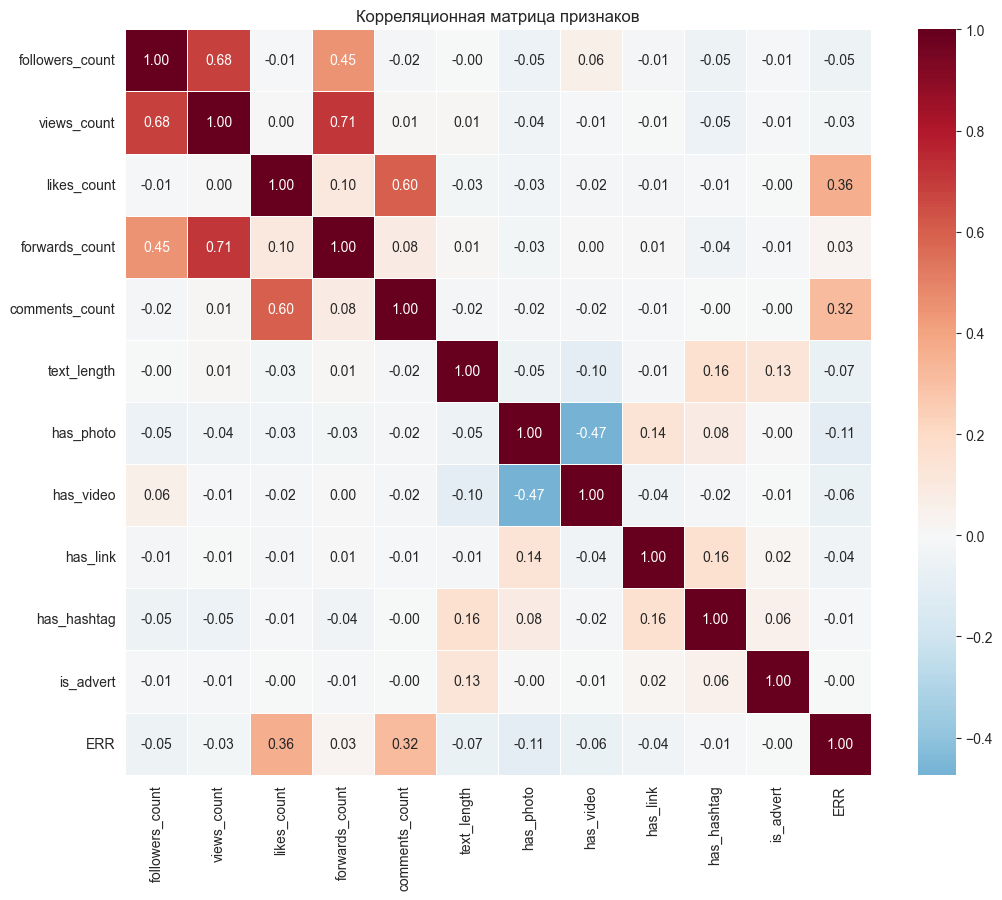

Корреляция с ERR:
ERR                1.000000
likes_count        0.362847
comments_count     0.317385
forwards_count     0.028433
is_advert         -0.002363
has_hashtag       -0.009455
views_count       -0.028483
has_link          -0.036416
followers_count   -0.048840
has_video         -0.062861
text_length       -0.067825
has_photo         -0.107501
Name: ERR, dtype: float64


In [44]:
# Корреляционная матрица
corr_cols = ["followers_count", "views_count", "likes_count", "forwards_count",
             "comments_count", "text_length", "has_photo", "has_video",
             "has_link", "has_hashtag", "is_advert", "ERR"]

corr = df[corr_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

print("Корреляция с ERR:")
print(corr["ERR"].sort_values(ascending=False))


## 3.5 Анализ рекламных постов (классификация по типу маркера)


Text(0.5, 1.0, 'ERR: платформа × реклама')

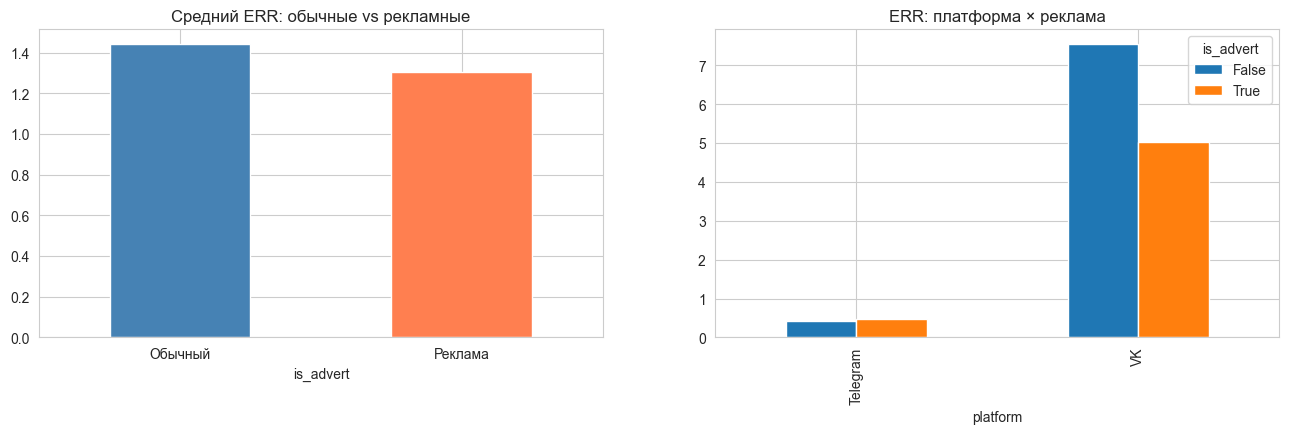

In [45]:
# ERR для рекламных vs обычных
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Средний ERR
df.groupby('is_advert')['ERR'].mean().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Средний ERR: обычные vs рекламные')
axes[0].set_xticklabels(['Обычный', 'Реклама'], rotation=0)

# По платформам
df.groupby(['platform','is_advert'])['ERR'].mean().unstack().plot(kind='bar', ax=axes[1])
axes[1].set_title('ERR: платформа × реклама')


## 4. Feature Engineering

In [46]:
# 4.1 Временные
df['published_dt'] = pd.to_datetime(df['published_at'], utc=True, errors='coerce')
df['hour'] = df['published_dt'].dt.hour
df['day_of_week'] = df['published_dt'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['published_dt'].dt.month
print('Временные: hour, day_of_week, is_weekend, month')

Временные: hour, day_of_week, is_weekend, month


In [47]:
# 4.2 Текстовые
def count_hashtags(text): return len(re.findall(r'#\w+', str(text)))
def count_links(text):    return len(re.findall(r'https?://', str(text)))
def count_mentions(text): return len(re.findall(r'@\w+', str(text)))
def count_emojis(text):
    emoji_pat = re.compile('['
        '\U0001F300-\U0001F9FF\U0001FA00-\U0001FA6F'
        '\U0001FA70-\U0001FAFF\U00002702-\U000027B0'
        '\U000024C2-\U0001F251]+', flags=re.UNICODE)
    return len(emoji_pat.findall(str(text)))

df['n_hashtags'] = df['post_text'].apply(count_hashtags)
df['n_links']    = df['post_text'].apply(count_links)
df['n_mentions'] = df['post_text'].apply(count_mentions)
df['n_emojis']   = df['post_text'].apply(count_emojis)
print('Текстовые: n_hashtags, n_links, n_mentions, n_emojis')

Текстовые: n_hashtags, n_links, n_mentions, n_emojis


In [48]:
# 4.3 Логарифмированные (для борьбы с long-tail)
df['log_followers']  = np.log1p(df['followers_count'])
df['log_views']      = np.log1p(df['views_count'])
df['log_engagement'] = np.log1p(df['total_engagement'])
df['log_ERR']        = np.log1p(df['ERR'])
print('Логарифмированные: log_followers, log_views, log_engagement, log_ERR')

Логарифмированные: log_followers, log_views, log_engagement, log_ERR


In [49]:
# 4.4 Бинарные
df['is_telegram']   = (df['platform'] == 'Telegram').astype(int)
df['has_any_media'] = (df['has_photo'] | df['has_video'] | df['has_document']).astype(int)
print('Бинарные: is_telegram, has_any_media')

Бинарные: is_telegram, has_any_media


In [50]:
# 4.5 Производные
df['text_density'] = np.where(
    df['n_hashtags'] + df['n_links'] > 0,
    df['text_length'] / (df['n_hashtags'] + df['n_links']),
    df['text_length']
)
print('Производные: text_density')

Производные: text_density


### 4.6 Агрегатные признаки канала 🆕

Средний ERR канала и частота публикаций — одни из сильнейших предикторов.

In [51]:
# Статистики по каналу
channel_stats = df.groupby('channel_username').agg(
    channel_avg_err=('ERR', 'mean'),
    channel_median_err=('ERR', 'median'),
    channel_posts_total=('post_id', 'count'),
    channel_avg_views=('views_count', 'mean'),
    channel_avg_text_len=('text_length', 'mean'),
).reset_index()

# Частота публикаций (постов в день)
channel_stats['channel_posts_per_day'] = (
    channel_stats['channel_posts_total'] / 30  # примерно за месяц
)

df = df.merge(channel_stats, on='channel_username', how='left')

print('Агрегаты канала добавлены:')
print([c for c in channel_stats.columns if c != 'channel_username'])

Агрегаты канала добавлены:
['channel_avg_err', 'channel_median_err', 'channel_posts_total', 'channel_avg_views', 'channel_avg_text_len', 'channel_posts_per_day']


## 5. Очистка текстов

In [52]:
def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['post_text'].apply(clean_text)
df['clean_text_length'] = df['clean_text'].apply(len)
print('clean_text, clean_text_length добавлены')

clean_text, clean_text_length добавлены


## 6. Разделение: EDA-датасет vs MODEL-датасет

**Ключевой момент:** в MODEL-датасет НЕ попадают , , ,  — они неизвестны до публикации.

In [53]:
EDA_COLUMNS = [
    "platform", "channel_username", "channel_title",
    "followers_count", "log_followers",
    "views_count", "likes_count", "forwards_count", "comments_count",
    "total_engagement", "log_views", "log_engagement",
    "is_advert", "has_photo", "has_video", "has_document",
    "has_link", "has_hashtag", "has_media", "has_any_media",
    "is_telegram",
    "post_text", "clean_text", "text_length", "clean_text_length",
    "n_hashtags", "n_links", "n_mentions", "n_emojis",
    "hour", "day_of_week", "is_weekend", "month",
    "text_density",
    "country", "city",
    "channel_avg_err", "channel_median_err",
    "channel_posts_total", "channel_posts_per_day",
    "channel_avg_views", "channel_avg_text_len",
    "ERR", "log_ERR",
    "published_at", "published_dt",
]

MODEL_FEATURES = [
    "followers_count", "log_followers",
    "hour", "day_of_week", "is_weekend", "month",
    "text_length", "clean_text_length",
    "n_hashtags", "n_links", "n_mentions", "n_emojis",
    "has_photo", "has_video", "has_document", "has_any_media",
    "has_link", "has_hashtag",
    "is_advert", "is_telegram",
    "country", "city",
    "text_density",
    "channel_avg_err", "channel_median_err",
    "channel_posts_total", "channel_posts_per_day",
    "channel_avg_views", "channel_avg_text_len",
]
TARGETS = ["ERR", "log_ERR"]
print(f"MODEL_FEATURES: {len(MODEL_FEATURES)}, TARGETS: {len(TARGETS)}")


MODEL_FEATURES: 29, TARGETS: 2


In [54]:
# Save both datasets
KEY_COLS = [c for c in ["platform", "channel_username", "post_id"] if c in df.columns]
model_cols = [c for c in MODEL_FEATURES if c in df.columns] + TARGETS + KEY_COLS
df_model = df[model_cols].copy()
df_model = df_model.dropna(subset=["ERR"])
cat_as_int = ["hour","day_of_week","month","is_weekend","is_advert","is_telegram",
             "has_photo","has_video","has_document","has_link","has_hashtag","has_any_media"]
for c in cat_as_int:
    if c in df_model.columns: df_model[c] = df_model[c].fillna(0).astype(int)
cat_as_str = ["country","city"]
for c in cat_as_str:
    if c in df_model.columns: df_model[c] = df_model[c].fillna("unknown").astype(str)
num_cols = df_model.select_dtypes(include="number").columns
df_model[num_cols] = df_model[num_cols].fillna(0)
df_model.to_csv("../data/processed/model_ready.csv", index=False)
df_eda = df[[c for c in EDA_COLUMNS if c in df.columns]].copy()
df_eda.to_csv("../data/processed/eda_full.csv", index=False)
print(f"MODEL: {df_model.shape} | EDA: {df_eda.shape}")
print(f"  Keys: {KEY_COLS}")


MODEL: (67410, 34) | EDA: (67410, 46)
  Keys: ['platform', 'channel_username', 'post_id']


## 7. Финальная визуализация: ERR по часу и дню

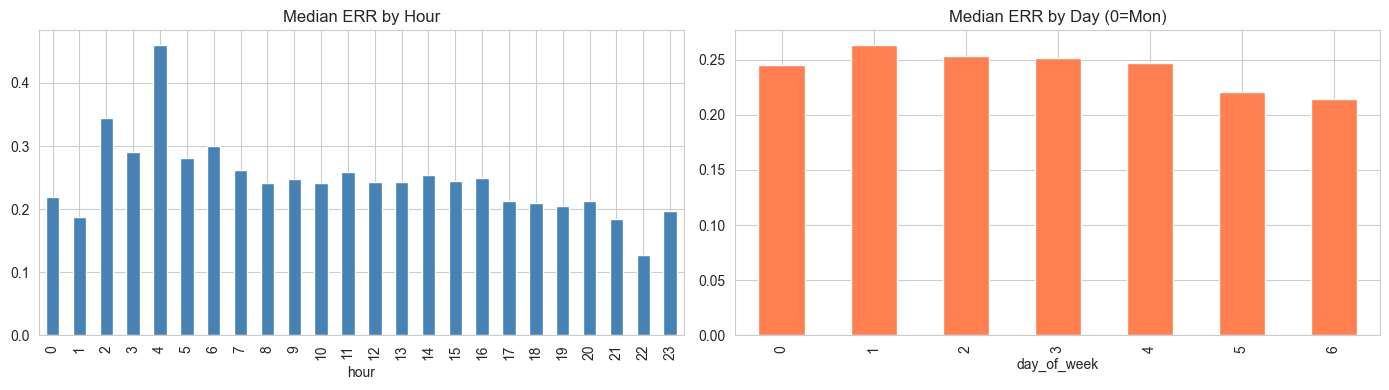

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_model.groupby('hour')['ERR'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median ERR by Hour')
df_model.groupby('day_of_week')['ERR'].median().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Median ERR by Day (0=Mon)')
plt.tight_layout()
plt.show()